## Imports

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

import sys

sys.path.append("..")

## Read in data

In [21]:
data = pd.read_csv("../data/Breast_Cancer.csv")

## Data Shape

In [22]:
print(f"Data Shape: {data.shape}")

Data Shape: (4024, 16)


## Data Columns

In [23]:
print(f"Current Data Columns: {sorted(data.columns)}")

Current Data Columns: ['6th Stage', 'A Stage', 'Age', 'Estrogen Status', 'Grade', 'Marital Status', 'N Stage', 'Progesterone Status', 'Race', 'Reginol Node Positive', 'Regional Node Examined', 'Status', 'Survival Months', 'T Stage ', 'Tumor Size', 'differentiate']


## Target Field

In [24]:
data["Status"].value_counts(dropna=False, normalize=True)

Status
Alive    0.846918
Dead     0.153082
Name: proportion, dtype: float64

## Create Target Flag

In [25]:
# Creating the 'Status' binary flag
data['target'] = data['Status'].apply(lambda x: 1 if x in ['Alive'] else 0)

# Printing unique value counts of the 'Target' binary flag with context
print("Unique Value Counts for 'Target' Flag:")
print(data["target"].value_counts())
print(f"Total Records: {len(data)}")
print(f"Total Deaths: {len(data) - data['target'].sum()}")

Unique Value Counts for 'Target' Flag:
target
1    3408
0     616
Name: count, dtype: int64
Total Records: 4024
Total Deaths: 616


## Target Distribution Over Time

In [26]:
# As discussed in 01_data_exploration, the date column needs to be converted to datetime format for proper grouping and analysis.

diagnosis_start = pd.Timestamp("2006-01-01")

data["Patient Start Date"] = diagnosis_start

# Calculate patient end date
data["Patient End Date"] = data["Survival Months"].apply(
    lambda months: diagnosis_start + pd.DateOffset(months=int(months))
)

# Survival Months remains as numeric

# Update date_fields
date_fields = ["Patient Start Date", "Patient End Date"]

In [27]:
df_grouped = (
    data.groupby([pd.Grouper(key="Patient End Date", freq="ME"), "target"])
    .size()
    .unstack(fill_value=0)
)

# Adjust the index to show the first day of the month
df_grouped.index = df_grouped.index - pd.offsets.MonthEnd(1) + pd.offsets.MonthBegin(1)

# Rename the columns for clarity
df_grouped.columns = ["Died", "Survived"]

# Add total and survival rate for better analysis
df_grouped['Total'] = df_grouped['Died'] + df_grouped['Survived']
df_grouped['Survival Rate'] = df_grouped['Survived'] / df_grouped['Total']

# Display the formatted DataFrame
df_grouped.head()

,Died,Survived,Total,Survival Rate
Patient End Date,,,,
2006-02-01,0,1,1,1.000000
2006-03-01,2,1,3,0.333333
2006-04-01,2,2,4,0.500000
2006-05-01,9,1,10,0.100000
2006-06-01,4,2,6,0.333333


## Plotting Distribution Over Time

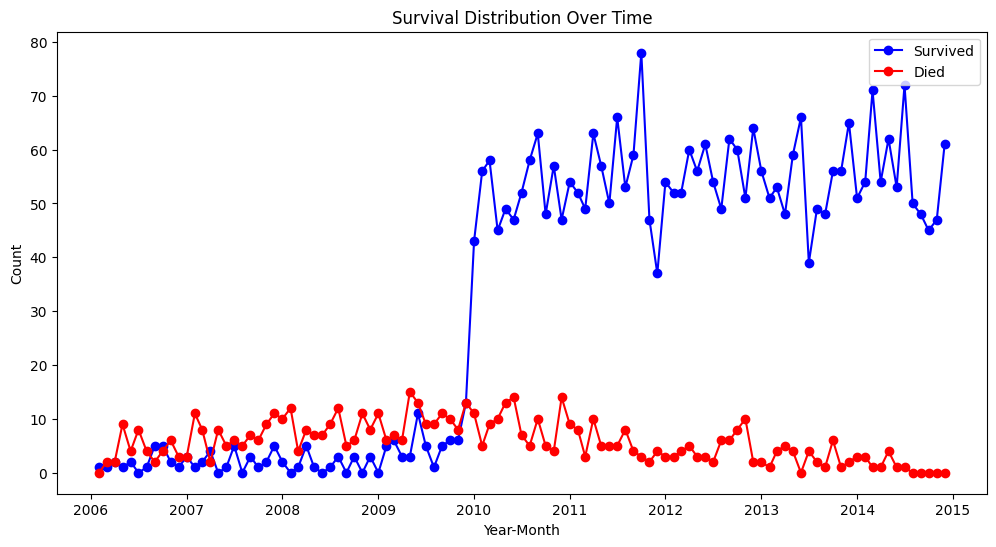

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(
    df_grouped.index,
    df_grouped["Survived"],
    marker="o",
    linestyle="-",
    label="Survived",
    color="blue",
)
plt.plot(
    df_grouped.index,
    df_grouped["Died"],
    marker="o",
    linestyle="-",
    label="Died",
    color="red",
)
plt.xlabel("Year-Month")
plt.ylabel("Count")
plt.title("Survival Distribution Over Time")
plt.legend()
plt.xticks(rotation=0)
plt.show()

This shows that the length of time someone is diagnosed with breast cancer the high chance there is for survival.

## Percentage Of Survival Over Time

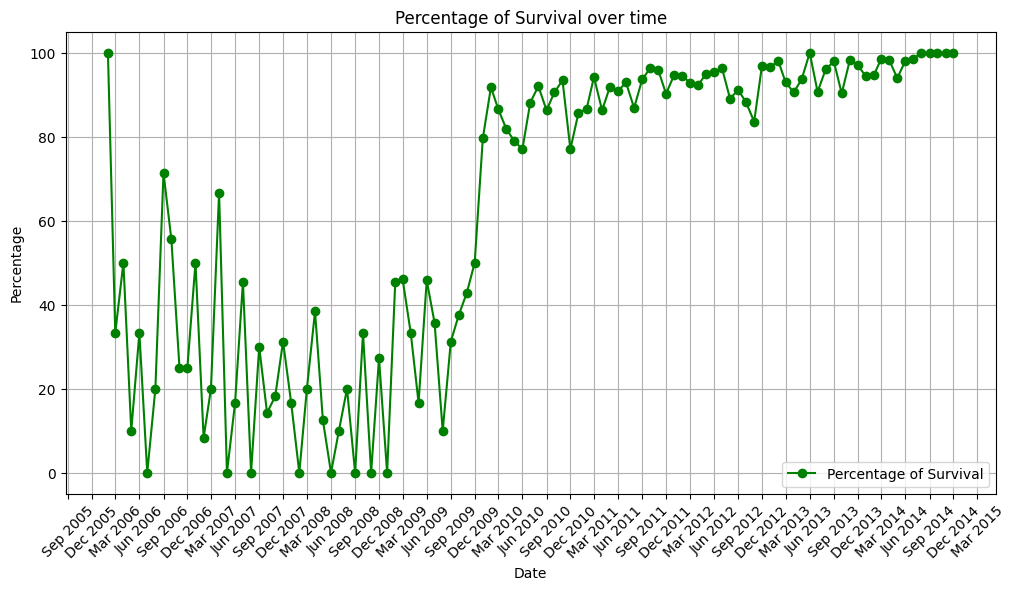

In [ ]:
df_grouped["Percentage_Survival"] = (
    df_grouped["Survived"] / (df_grouped["Survived"] + df_grouped["Died"])
) * 100

plt.figure(figsize=(12, 6))
plt.plot(
    df_grouped.index,
    df_grouped["Percentage_Survival"],
    marker="o",
    linestyle="-",
    label="Percentage of Survival",
    color="green",
)

# adding quarters on the x-axis as difficult to read with months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xlabel("Date")
plt.ylabel("Percentage")
plt.title("Percentage of Survival over time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()